# ESC SPMe: Plot I, V, T, and SOC for all cells

Note to self: currently set up to plot "fit" using 100A params with data input to illustrate error from using  wrong parameters  vs error propagation 

Conclusions: Because the model overpredicts current, I also let it overpredict temperature as opposed to tuning Cp and h to fit the data. Using the lumped thermal model, we see that the effect of decomposition heating is minimal, which was expected. SEI decomposition is also the only decomp reaction contributing to heating which was expected.  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import pybamm
print(pybamm.__path__[0])
from scipy import integrate, constants
import Tran2024
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': 'Computer Modern',
    'font.sans-serif': ['Computer Modern'],
    'font.size': 9,
})
%matplotlib widget

C:\Users\Vivian\University of Michigan Dropbox\Vivian Tran\from_box\Research\PyBaMM\PyBaMM2024\src\pybamm


In [2]:
class ExternalCircuitResistanceFunction():
    def __call__(self, variables):
        I = variables["Current [A]"]
        V = variables["Terminal voltage [V]"]
        R_ext = pybamm.FunctionParameter("External short resistance [Ohm]",  {"Time [s]": pybamm.t}) 
        R_tab = pybamm.FunctionParameter("Tabbing resistance [Ohm]",  {"Time [s]": pybamm.t})
        return V/I - (R_ext + R_tab)

# Load data

In [3]:
Q_nom = 4.6
t_end = 15*60

def load_data(SOC_0, SOC_name):
    # load data import ESC data from file
    raw_data = pd.read_csv("ESC_"+  SOC_name + "SOC_full.csv")
    esc_start = raw_data[-raw_data['Current Shunt']>1].index[0]-1
    t_end_desired = raw_data['Time (s)'].loc[esc_start]+t_end
    esc_end = raw_data[(raw_data['Time (s)']>t_end_desired) | ((-raw_data['Current Shunt']<1) & (raw_data['Time (s)']>esc_start))].index[0]
    # T_amb = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) | (raw_data['Cell Temperature'] >0)])
    data = raw_data[['Time (s)', 'Voltage (V)', 'Cell Temperature', 'Current Shunt', 'Force']].loc[esc_start:esc_end].copy()
    data['Cell Temperature2'] = data['Cell Temperature'].copy() #make a copy 
    data.loc[data['Cell Temperature']>140, 'Cell Temperature'] = None #filter and interpolate original
    data.interpolate(inplace=True) #fill in nans for df
    data.loc[data['Cell Temperature2']>140, 'Cell Temperature2'] = None #filter copy, NO interp
    data['Current Shunt'] = -data['Current Shunt']
    data['Time (s)'] = data['Time (s)'] - data['Time (s)'].loc[esc_start]
    data['Force'] = data['Force']*9.81
    df_labels = ['t', 'V', 'Temp','I', 'F','Temp2']
    data = data.set_axis(labels = df_labels, axis=1, copy=False)
    data['I_C'] = data.I/Q_nom 
    AhT_calculated = integrate.cumulative_trapezoid(abs(data.I), data.t-data.t.iloc[0])/3600
    AhT_calculated = np.append(AhT_calculated,AhT_calculated[-1])
    data['SOC'] = SOC_0 - AhT_calculated/Q_nom # load data import ESC data from file
    if SOC_name =='100B':
        data['V'][(data.t[0:-1]>800) & (data.V>0.1)]  = None # remove voltage recovery on 100B

    T_amb_0 = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) & (raw_data['Cell Temperature'] >0)])
    data.reset_index(drop=True, inplace=True)

    return data, T_amb_0

display(load_data(1, '100A')[0])

,t,V,Temp,I,F,Temp2,I_C,SOC
0,0.000,4.176052,24.111259,0.824988,135.614645,24.111259,0.179345,0.999296
1,0.100,1.564826,24.140908,232.204691,136.217933,24.140908,50.479281,0.997894
2,0.200,1.543099,24.121142,232.228600,136.313189,24.121142,50.484478,0.996493
3,0.300,1.521092,24.150790,231.838083,136.789469,24.150790,50.399583,0.995090
4,0.400,1.515830,24.121142,232.698815,136.789469,24.121142,50.586699,0.993685
...,...,...,...,...,...,...,...,...
8996,899.602,0.019834,69.558434,2.151935,10.098965,69.558434,0.467812,0.302791
8997,899.702,0.019834,69.548850,2.163890,10.225974,69.548850,0.470411,0.302777
8998,899.802,0.019754,69.568017,2.279450,9.971957,69.568017,0.495533,0.302764
8999,899.902,0.019874,69.548850,2.143966,10.416486,69.548850,0.466079,0.302751


# Run simulations

In [4]:
def sim_ESC(SOC_0, SOC_name, param_update = {}, SOC_param = ""):    # need to "data,T_amb_0 = load_data(SOC_0, SOC_name)" before running
    data, T_amb = load_data(SOC_0, SOC_name)
    R_tab = pybamm.Parameter("Tabbing resistance [Ohm]")
    R_ext = pybamm.Parameter("External resistance [Ohm]")

    R_tabs = {'100A':  0.0086, '100B':0.0049, '75':0.0078+0.0005, '50':0.007-0.0007}
    R_escs = {'100A':  0.0067, '100B':0.004, '75':0.0067-0.0005, '50':0.0067+0.0007}

    if SOC_param =="":
        SOC_param = SOC_name
    option = {
        "thermal": "lumped",
        "heat of mixing": "true",
        "decomposition": "true", 
        "operating mode": ExternalCircuitResistanceFunction(),
        "cell geometry": "arbitrary",
        "venting":"true",
    }

    model = pybamm.lithium_ion.SPMe(options = option)
    chemistry = Tran2024.get_parameter_values()
    param = pybamm.ParameterValues(chemistry)

    param.update({
        "Tabbing resistance [Ohm]":  R_tabs[SOC_name],#0.0041,D
        "External short resistance [Ohm]": R_escs[SOC_name], # 0.0067
    }, check_already_exists = False)

    param.update(param_update, check_already_exists = False)
    
    V = model.variables["Terminal voltage [V]"]
    I = model.variables["Current [A]"]
    model.variables.update({
        "Terminal voltage [V]": V - I*R_tab,
        "Actual resistance [Ohm]":V/I,
        }
    )
    
    dt = 0.1
    t_eval = np.arange(0, t_end, dt) #16*60
    solver = pybamm.CasadiSolver(mode="safe", dt_max = 10) #, extra_options_setup={"max_num_steps": 10000}
    sim = pybamm.Simulation(model, parameter_values = param, solver=solver) # var_pts=var_pts
    solution = sim.solve( initial_soc=SOC_0, t_eval = t_eval)
    return solution



In [5]:
SOC_names = ['100A', '100B','75', '50'] # 
SOC_0s = {'100A': 1, '100B': 1, '75': 0.75, '50': 0.5}

datas = []
T_ambs = []
solutions_fit = []
for SOC_name in SOC_names: 
    print(SOC_name)

    # load data and sim 
    SOC_0 = SOC_0s[SOC_name]
    data,T_amb = load_data(SOC_0, SOC_name)
    solution_fit = sim_ESC(SOC_0, SOC_name, SOC_param = '100A')
    solutions_fit.append(solution_fit)
    datas.append(data)
    T_ambs.append(T_amb)


100A
100B
75
50


In [6]:
# save sim results to csv for matlab plotting
for (sol, soc_name) in zip(solutions_fit, SOC_names):
    t = sol["Time [s]"].entries
    I = sol['Current [A]'](t=t)
    V = sol['Terminal voltage [V]'](t=t)
    T = sol['Volume-averaged cell temperature [K]'](t=t)
    print(max(T)-273.15)
    x_sei = sol['Fraction of Li in SEI'](t=t)

#     sim_results = pd.DataFrame.from_dict({'t':t, 'I':I, 'V':V, "T":T, 'x_sei':x_sei})
#     sim_results.to_csv(r'C:\Users\Vivian\University of Michigan Dropbox\Vivian Tran\from_box\Research\PyBaMM\PyBaMM\pybamm_simulink\model_validation\pybamm_ESC_sim_results\pybamm_' + soc_name +'_ESC_sim_results.csv')


138.3305566611569
143.66161753964565
103.39656538913363
71.70808997660987


# PLOT: Simulation with fitted values

## Linear time with inset

1
1
0.75
0.5


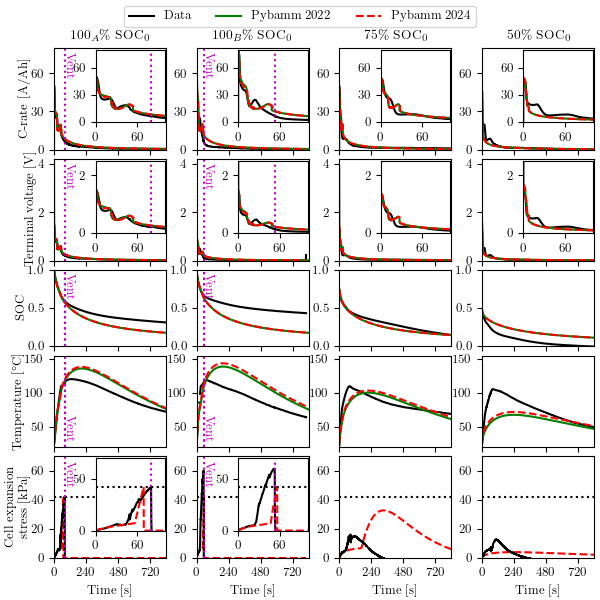

,SOC_names,dSOCs_f,dT_maxs,dsigma_maxs,dt_vents,rmses_I,rmses_V,rmses_T
0,100A,-0.13,18.05,-0.16,-10.6,1.29,0.04,15.15
1,100B,-0.25,24.84,-18.09,3.6,2.50,0.05,27.59
2,75,0.01,-6.42,16.65,3.6,1.42,0.05,9.36
3,50,0.12,-33.86,-8.57,3.6,1.81,0.04,16.99


In [8]:
%matplotlib widget
chemistry = Tran2024.get_parameter_values()
param = pybamm.ParameterValues(chemistry)
# L_y = param.evaluate(pybamm.geometric_parameters.L_y)
# L_z = param.evaluate(pybamm.geometric_parameters.L_z)
# L = param.evaluate(pybamm.geometric_parameters.L)
liion = pybamm.LithiumIonParameters()

V_cell = param.evaluate(liion.V_cell)
delta_sigma_max = 42.35277961

sim_set_labels = ['Pybamm 2024'] #Model with parameters from Cell 100A
fit_labels=[r'$\dot{{\tilde{Q}}}$ data input', r'$\tilde{T}$ data input'] #=$\tilde{I}\Delta$V 
# fig, ax= plt.subplots(5, len(SOC_names), figsize=(6.75, 7), sharex=True) #, , gridspec_kw = {'wspace':0.4, 'hspace':0.15}, ,constrained_layout=True # paper 
# plt.subplots_adjust(left=0.09, bottom=0.07, right=0.99, top=0.925, wspace=0.27, hspace=0.1)

# ECS poster
fig, ax= plt.subplots(5, len(SOC_names), figsize=(6, 6), sharex=True, height_ratios=[1,1,0.75,.9, 1]) #, , gridspec_kw = {'wspace':0.4, 'hspace':0.15}, ,constrained_layout=True # paper 
plt.subplots_adjust(left=0.09, bottom=0.07, right=0.99, top=0.92, wspace=0.27, hspace=0.1)

ax_inset = ax.copy()
# ax = ax.flatten()
linestyles = ['--',':','-.']
sim_colors = ['r','b','g']
fit_colors = ['g','b']
ls_data_input = ':'

# init metric logging
SOC_names_list = []
dSOCs_f = []
dT_maxs = []
dsigma_maxs = []
rmses_I = []
rmses_V = []
rmses_T = []
rmses_sigma = []
dt_vents = []

# for each cell...
for k, solutions in enumerate([solutions_fit]): 
    for j, (solution, data, SOC_name) in enumerate(zip(solutions, datas, SOC_names)):     #,solution_thermal_fit,solution_venting_fit,solutions_thermal_fit, solutions_venting_fit,
        fn = r'C:\Users\Vivian\University of Michigan Dropbox\Vivian Tran\from_box\Research\PyBaMM\PyBaMM\pybamm_simulink\model_validation\pybamm_ESC_sim_results\pybamm_' + SOC_name +'_ESC_sim_results.pkl'
        with open(fn, 'rb') as f:
            # Load the object from the file
            sim_data = pickle.load(f)
        sim_data = pd.DataFrame.from_dict(sim_data)

        # sim plot vars
        SOC_0 = SOC_0s[SOC_name]
        print(SOC_0)
        t = data.t #solution["Time [s]"].entries
        I = solution['C-rate'](t=t)
        I_A = solution['Current [A]'](t=t)
        Vt = solution["Terminal voltage [V]"](t=t)
        AhT_calculated = integrate.cumtrapz(abs(I), t)/3600
        AhT_calculated = np.append(AhT_calculated,AhT_calculated[-1])
        SOC = SOC_0- AhT_calculated
        T = solution['Volume-averaged cell temperature [K]'](t=t) - 273.15
        Q = solution['Volume-averaged total heating [W.m-3]'](t=t)*V_cell
        delta_sigma = solution["Cell expansion stress [kPa]"](t)

        # plot settings
        data_color = 'k'
        sim_color = sim_colors[k]
        sim_ls = '--'
        t_end_inset = 100
        inset_pos = [.37, .27, 1-0.01-0.37, 1-0.02-.27] #[x0, y0, width, height]

        sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
        data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0

        if k ==0: 
            ax[0,j].plot(data.t,data.I/param['Nominal cell capacity [A.h]'], label='Data',color = data_color)
            ax[0,j].plot(sim_data['Time [s]'],sim_data['Current [A]']/param['Nominal cell capacity [A.h]'], label='Pybamm 2022',color = 'g')
            ax[0,j].set_yticks(np.arange(0,80,30))
            ax_inset[0,j] = ax[0,j].inset_axes(inset_pos, xlim = (0,t_end_inset), ylim = (0,80), xticks=[0,60], yticks=np.arange(0,80,30))  # subregion of original plot yticklabels=[]
            ax_inset[0,j].plot(data.t,data.I/param['Nominal cell capacity [A.h]'], label='Data',color = data_color)
            ax_inset[0,j].plot(sim_data['Time [s]'],sim_data['Current [A]']/param['Nominal cell capacity [A.h]'], label='Pybamm 2022',color = 'g')

            ax[1,j].plot(data.t, data.V, color = data_color)
            ax[1,j].plot(sim_data['Time [s]'],sim_data['Terminal voltage [V]'], label='Pybamm 2022',color = 'g')
            ax_inset[1,j] = ax[1,j].inset_axes(inset_pos, xlim = (0,t_end_inset), ylim = (0,2.5), xticks=[0,60])  # subregion of original plot yticklabels=[]
            ax_inset[1,j].plot(data.t,data.V, label='Data',color = data_color)
            ax_inset[1,j].plot(sim_data['Time [s]'],sim_data['Terminal voltage [V]'], label='Pybamm 2022',color = 'g')

            ax[2,j].plot(data.t, data.SOC, color = data_color)
            AhT_calculated_sim_data = integrate.cumtrapz(abs(sim_data['Current [A]']), sim_data['Time [s]'])/3600/param['Nominal cell capacity [A.h]']
            AhT_calculated_sim_data = np.append(AhT_calculated_sim_data,AhT_calculated_sim_data[-1])
            SOC_sim_data = SOC_0- AhT_calculated_sim_data
            ax[2,j].plot(sim_data['Time [s]'],SOC_sim_data, label='Pybamm 2022',color = 'g')

            ax[3,j].plot(data.t, data.Temp2,  color = data_color)
            ax[3,j].plot(sim_data['Time [s]'],sim_data['Volume-averaged cell temperature [K]']-273.15, label='Pybamm 2022',color = 'g')
            # ax2 = ax[3,j].twinx()
            # ax2.plot(data.t,Q)
            # ax[3,j].plot(data.t, solution_thermal_fit['Volume-averaged cell temperature [K]'](t=t) - 273.15,  linestyle= ls_data_input, color = fit_colors[0], label=fit_labels[0])

            ax[3,j].set_xticks(np.arange(0, 60*14, 60*4))
            # if j == len(solutions_thermal_fit)-1:
                # ax[3,j].legend(borderpad = 0.1, loc='upper center', handletextpad = 0.5)
            # delta_sigma_fit = solution_venting_fit["Cell expansion stress [kPa]"](t)
            # delta_sigma_plot = delta_sigma_fit.copy()
            # vent_check = np.argmax(delta_sigma_plot>delta_sigma_max)
            # if vent_check > 0:
            #     delta_sigma_plot[vent_check::] = 0  
            #     t_vent_sim = data.t[np.where(delta_sigma_plot==0)[0][0]]
            #     try: 
            #         t_vent_data = data.t.iloc[np.where(data_sigma == max(data_sigma))[0][0]]
            #         e_t_vent = t_vent_sim -  t_vent_data
            #     except: 
            #         t_vent_data = data.t.iloc[-1]
            #         e_t_vent = float('nan')
            ax[4,j].plot(data.t, data_sigma, color = data_color, label ="__nolabel__") #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
            # ax[4,j].plot(data.t, delta_sigma_plot,linestyle=ls_data_input, color = fit_colors[1], label=fit_labels[1],zorder = 10)
            # if j == len(solutions_venting_fit)-1:
            #     ax[4,j].legend(borderpad = 0.1, loc='upper center', handletextpad = 0.5)
            if SOC_0 ==1:
                ax_inset[4,j] = ax[4,j].inset_axes(inset_pos, xlim = (0,t_end_inset), ylim = (0,70), xticks=[0,60])  # subregion of original plot yticklabels=[]
                ax_inset[4,j].plot(data.t, data_sigma, label='Data',color = data_color)
                # ax_inset[4,j].plot(data.t, delta_sigma_plot,linestyle=ls_data_input, color = fit_colors[1], label=fit_labels[1],zorder = 10)


        # C-rate
        i = 0
        ax[i,j].plot(t, I, linestyle= sim_ls, color = sim_color, label=sim_set_labels[k])
        if j ==0:
            ax[i,j].set_ylabel("C-rate [A/Ah]", labelpad=1)
        ax[i,j].set_ylim([0,80])
        ax_inset[0,j].plot(t, I, linestyle= sim_ls, color = sim_color, label=sim_set_labels[k])
        # ax[i,j].set_title('Cell ' + SOC_names[j], fontsize = 9.5)
        
        # set column name/ title 
        if SOC_name == '100A':
            ax[i,j].set_title( str(int(SOC_0*100)) + '$_A$\% SOC$_0$', fontsize = 9.5) #ECS poster

        elif SOC_name == '100B':
            ax[i,j].set_title( str(int(SOC_0*100)) + '$_B$\% SOC$_0$', fontsize = 9.5) #ECS poster

        else:
            ax[i,j].set_title( str(int(SOC_0*100)) + '\% SOC$_0$', fontsize = 9.5) #ECS poster

        # Terminal voltage
        i = 1
        ax[i,j].plot(t, Vt, linestyle= sim_ls, color = sim_color, label=sim_set_labels[k])
        if j ==0:
            ax[i,j].set_ylabel('Terminal voltage [V]', labelpad=1)
        ax[i,j].set_ylim([0,4.2])
        ax_inset[i,j].plot(t,Vt, linestyle= sim_ls, color = sim_color, label=sim_set_labels[k])


        # SOC
        i = 2
        ax[i,j].plot(t,SOC, linestyle= sim_ls, color = sim_color, label=sim_set_labels[k])
        if j ==0:
            ax[i,j].set_ylabel("SOC", labelpad=1)
        ax[i,j].set_ylim([0,1])

        # Temperature
        i = 3
        ax[i,j].plot(data.t, T,  linestyle= sim_ls, color = sim_color, label ="__nolabel__")
        if j ==0:
            ax[i,j].set_ylabel("Temperature [$^\circ$C]",labelpad=1)
        ax[i,j].set_ylim([20,155])

        # delta_sigma
        i = 4
        delta_sigma_plot = delta_sigma.copy()
        vent_check = np.argmax(delta_sigma_plot>delta_sigma_max)
        if vent_check > 0:
            delta_sigma_plot[vent_check::] = 0  
            t_vent_sim = data.t[np.where(delta_sigma_plot==0)[0][0]]
            try: 
                t_vent_data = data.t.iloc[np.where(data_sigma == max(data_sigma))[0][0]]
                e_t_vent = t_vent_sim -  t_vent_data

            except: 
                t_vent_data = data.t.iloc[-1]
                e_t_vent = float('nan')
            # print(e_t_vent)
        ax[i,j].plot(data.t, delta_sigma_plot,linestyle=sim_ls, color = sim_color, label = sim_set_labels[k], zorder = 1)
        ax[i,j].set_ylim([0,70])
        ax[i,j].plot([data.t.iloc[0], data.t.iloc[-1]], delta_sigma_max*np.array([1,1]) , linestyle=':', color = data_color, label ="__nolabel__") #(out.P_est-P_atm)/1000-sigma_0/1000
        if j ==0:
            ax[i,j].set_ylabel("Cell expansion \nstress [kPa]",labelpad=1) #$\Delta \sigma$ 
        ax[i,j].set_xlabel("Time [s]")
        if SOC_0 ==1:
            ax_inset[4,j].plot(data.t, delta_sigma_plot, linestyle=sim_ls, color = sim_color)
            ax_inset[4,j].plot([data.t.iloc[0], data.t.iloc[-1]], delta_sigma_max*np.array([1,1]) , linestyle=':', color = data_color, label ="__nolabel__")


        # plot vent times from data
        if SOC_0==1:# and (l == len(solutions)-1):
            for i in range(0,5):
                t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
                T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
                ylims = ax[i,j].get_ylim()
                ax[i,j].plot([t_vent]*2, list(ylims), color = 'm', linestyle = ':')
                if i in [3]: #Temperature
                    ax[i,j].annotate('Vent', xy=(t_vent, np.diff(ylims)*0.05+ ylims[0]), rotation=-90, color = 'm', verticalalignment = 'bottom')
                else: 
                    ax[i,j].annotate('Vent', xy=(t_vent, np.diff(ylims)*0.95+ ylims[0]), rotation=-90, color = 'm', verticalalignment = 'top')
                ax[i,j].set_ylim(ylims) # keep original limits
                ylims_inset= ax_inset[i,j].get_ylim()
                ax_inset[i,j].plot([t_vent]*2, list(ylims_inset), color = 'm', linestyle = ':')
                # ax_inset[i,j].annotate('Vent', xy=(t_vent, np.diff(ylims_inset)*0.95+ ylims_inset[0]), rotation=-90, color = 'm', verticalalignment = 'top')
                ax_inset[i,j].set_ylim(ylims_inset) # keep original limits

        
        # SAVE METRICS
        SOC_names_list.append(SOC_names[j])
        dSOCs_f.append(SOC[np.where(~np.isnan(SOC))[0][-1]] - data.SOC.iloc[-1]) #last non-nan value
        dT_maxs.append(max(T)-max(data.Temp))
        dsigma_maxs.append(max(delta_sigma_plot) - max(data_sigma))
        try: 
            dt_vents.append(e_t_vent)
        except:
            dt_vents.append('-')

        # calculate errors
        e_I = I - data.I/param['Nominal cell capacity [A.h]'] 
        # print(max(abs(e_I[1:-1])))
        e_V = Vt - data.V 
        e_T = T-data.Temp.iloc[0:len(T)]
        # e_sigma = delta_sigma_plot[t<min(t_vent_data,t_vent_sim)] -  data_sigma[t<min(t_vent_data,t_vent_sim)]
        rmses_I.append(np.sqrt(np.mean(np.square(e_I))))
        rmses_V.append(np.sqrt(np.mean(np.square(e_V))))
        rmses_T.append(np.sqrt(np.mean(np.square(e_T))))
        # rmses_sigma.append(np.sqrt(np.mean(np.square(e_sigma))))

handles, labels = ax[0,0].get_legend_handles_labels()

fig.legend(handles, labels, loc='upper center', ncol=4,  bbox_to_anchor=(0.5, 1)) #,bbox_transform=ax[0,1].transAxes
plt.xlim([0,60*14])
# plt.tight_layout()
# plt.savefig('./figs/all_ESC_combined_linear_100A_vs_fit_insets.eps', dpi = 300,) #, pad_inches=0.2  bbox_inches='tight'
plt.savefig('./figs/all_ESC_combined_linear_100A_vs_fit_insets.jpg', dpi = 300,) #, pad_inches=0.2  bbox_inches='tight'

plt.show()

df = pd.DataFrame(list(zip(SOC_names_list,dSOCs_f , dT_maxs, dsigma_maxs, dt_vents, rmses_I, rmses_V, rmses_T)), #,rmses_sigma
               columns =['SOC_names','dSOCs_f' , 'dT_maxs', 'dsigma_maxs', 'dt_vents', 'rmses_I', 'rmses_V', 'rmses_T',]) #'rmses_sigma'
display(round(df,2))
# plt.rcParams.update({
#     'font.size': 9,
# })


## Sim thermal with Q input

In [8]:
def ocv(soc): # from C/10 with 15th-order polynomial 
    p0 = np.array([0.018506268107831,  -0.136071028323453, 
            0.443060938604833,  -0.839776753517996,   1.024213621638298, 
            -0.839264034243947,   0.470188190051651,  -0.183011124631359, 
            0.053509361841394,  -0.015162911494282,   0.005025031383283,
            -0.001474328544519, 0.000287406587189, -0.000032455129489, 
            0.000001937547848,  0.000000299017470
        ])*1e7
    return np.polyval(p0,soc)

## Thermal model verification

In [9]:
chemistry = Tran2024.get_parameter_values()
param = pybamm.ParameterValues(chemistry)
liion = pybamm.LithiumIonParameters()
# print(param.evaluate(liion.L_x)/param.evaluate(liion.p.L))

# print(130*89/1e6*2 + 5.5*89/1e6*2 + 130*5.5/1e6*2)
# print(param.evaluate(liion.V_cell))
# print(130*89*5.5/1e9)

In [10]:
def sim_thermal(t, Q):  
    chemistry = Tran2024.get_parameter_values()
    param = pybamm.ParameterValues(chemistry)
    liion = pybamm.LithiumIonParameters()

    # Define input and output
    T_vol_av = pybamm.Variable("Volume-averaged cell temperature [K]")
    Q_vol_av = pybamm.InputParameter("Volume-averaged total heating [W.m-3]") # instead of external variable
    model = pybamm.BaseModel()
    model.variables = {
        "Volume-averaged cell temperature [K]": T_vol_av,
    }

    # Newton cooling, accounting for surface area to volume ratio 
    V = param.evaluate(liion.V_cell)
    # V = param.evaluate(liion.L) *param.evaluate(liion.L_y) *param.evaluate(liion.L_z) 
    T_amb = pybamm.Scalar(273.15 + 25)# param.evaluate(liion.T_amb_av) # self._yz_average( param.evaluate(liion.T_amb(y, z, pybamm.t))) #
    # A_cool = 2*(param.evaluate(liion.L) *param.evaluate(liion.L_z)  + param.evaluate(liion.L) *param.evaluate(liion.L_y) + param.evaluate(liion.L_y) *param.evaluate(liion.L_z) )
    A_cool = param.evaluate(liion.A_cooling)
    Q_cool_W = -param.evaluate(liion.h_total) * A_cool * (T_vol_av - T_amb) 
    Q_cool_vol_av = Q_cool_W / V

    model.variables.update({
        "Lumped total cooling [W.m-3]": Q_cool_vol_av,
    })

    # RHS
    rho_c_p_eff_av = param.evaluate(liion.rho_c_p_eff(T_vol_av))
    model.rhs = {
        T_vol_av: (Q_vol_av + Q_cool_vol_av) / rho_c_p_eff_av
    }

    # set initial conditions
    T_init = param.evaluate(liion.T_init)
    model.initial_conditions = {T_vol_av: pybamm.Scalar(T_init)}

    # discretize
    disc = pybamm.Discretisation()  # use the default discretisation
    disc.process_model(model)

    # solve
    sim = pybamm.Simulation(model)
    # V_cell_norm = param.evaluate(liion.L) *param.evaluate(liion.L_y) *param.evaluate(liion.L_z) 
    # V = param.evaluate(liion.V_cell)
    for i,q in enumerate(Q[0:-1]):
        dt = t[i+1]-t[i]
        inputs = {"Volume-averaged total heating [W.m-3]": q} 
        sim.step(dt, inputs=inputs)
    return sim

In [11]:
# print(V_nom)
# print(param.evaluate(liion.L_x) *param.evaluate(liion.L_y) *param.evaluate(liion.L_z))

100A
100B
75
50


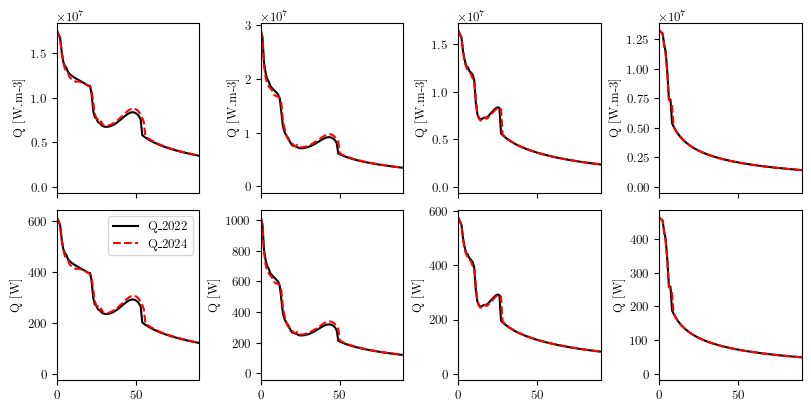

In [23]:
solutions_thermal_fit = []
plt.close('all')
fig, axs = plt.subplots(2, len(SOC_names), figsize=(8, 4), sharex=True, constrained_layout=True)#, constrained_layout=True
# axs = axs.flatten()
V_nom = param.evaluate(liion.L) *param.evaluate(liion.L_y) *param.evaluate(liion.L_z)
V_cell = param.evaluate(liion.V_cell)
for j, (SOC_name,data,solution) in enumerate(zip(SOC_names, datas,solutions_fit)):
    print(SOC_name)
    fn = r'C:\Users\Vivian\University of Michigan Dropbox\Vivian Tran\from_box\Research\PyBaMM\PyBaMM\pybamm_simulink\model_validation\pybamm_ESC_sim_results\pybamm_' + SOC_name +'_ESC_sim_results.pkl'
    with open(fn, 'rb') as f:
        # Load the object from the file
        sim_data = pickle.load(f)
    sim_data = pd.DataFrame.from_dict(sim_data)
    t_data = sim_data['Time [s]'].iloc[range(0,len(sim_data),10)]
    Q_vol_av_data = sim_data['Volume-averaged total heating [W.m-3]'].iloc[range(0,len(sim_data),10)]

    # select data and simulate
    sim_data_2024 = solution
    t_data_2024 = sim_data_2024['Time [s]'](t=range(0,15*60))
    Q_vol_av_data_2024 = sim_data_2024['X-averaged total heating [W.m-3]'](t=t_data_2024)#*V_cell
     
    # plot to compare
    ax = axs[0,j]
    ax.plot(t_data, Q_vol_av_data, 'k', label = 'Q_2022')
    ax.plot(t_data_2024, Q_vol_av_data_2024, '--r', label = 'Q_2024')
    ax.set_ylabel('Q [W.m-3]')

    # plot to compare
    ax = axs[1,j]
    ax.plot(t_data, Q_vol_av_data*V_nom, 'k', label = 'Q_2022')
    ax.plot(t_data_2024, sim_data_2024['Total heating [W]'](t=t_data_2024), '--r', label = 'Q_2024')
    ax.set_ylabel('Q [W]')
    # ax.set_ylim([20,150])
    ax.set_xlim([0,90])
    if j==0:
        ax.legend()

100A
100B
75
50


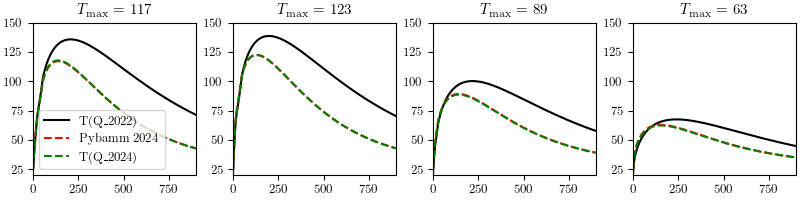

In [19]:
solutions_thermal_fit = []
plt.close('all')
fig, axs = plt.subplots(1, len(SOC_names), figsize=(8, 2), sharex=True, constrained_layout=True)#, constrained_layout=True
axs = axs.flatten()
for j, (SOC_name,data,solution_pybamm_model) in enumerate(zip(SOC_names, datas,solutions_fit)):
    print(SOC_name)
    fn = r'C:\Users\Vivian\University of Michigan Dropbox\Vivian Tran\from_box\Research\PyBaMM\PyBaMM\pybamm_simulink\model_validation\pybamm_ESC_sim_results\pybamm_' + SOC_name +'_ESC_sim_results.pkl'
    with open(fn, 'rb') as f:
        # Load the object from the file
        sim_data = pickle.load(f)
    sim_data = pd.DataFrame.from_dict(sim_data)
    t_data = sim_data['Time [s]'].iloc[range(0,len(sim_data),10)]
    Q_vol_av_data = sim_data['Volume-averaged total heating [W.m-3]'].iloc[range(0,len(sim_data),10)]
    T_vol_av_data = sim_data['Volume-averaged cell temperature [K]'].iloc[range(0,len(sim_data),10)]
    sim_data_input = sim_thermal(t_data.to_numpy(), Q_vol_av_data.to_numpy())
    # solutions_thermal_fit.append(sim_data_input.solution)

    # select data and simulate
    sim_data_2024 = solution_pybamm_model
    t_data_2024 = sim_data_2024['Time [s]'](t=range(0,15*60))
    Q_vol_av_data_2024 = sim_data_2024['Volume-averaged total heating [W.m-3]'](t=t_data_2024)
    T_vol_av_data_2024 = sim_data_2024['Volume-averaged cell temperature [K]'](t=t_data_2024)
    sim_data_input_2024 = sim_thermal(t_data_2024, Q_vol_av_data_2024)
    # solutions_thermal_fit.append(sim_data_input.solution)
     
    # plot to compare
    ax = axs[j]
    sol = sim_data_input.solution
    T_sim = sol['Volume-averaged cell temperature [K]'](t=t_data)
    ax.plot(t_data, T_vol_av_data-273.15, 'k', label = 'T(Q_2022)')
    ax.plot(t_data, T_sim-273.15, '--r', label = 'Pybamm 2024')
    ax.plot(t_data_2024, T_vol_av_data_2024-273.15, '--g', label = 'T(Q_2024)')

    ax.set_ylim([20,150])
    ax.set_xlim([0,t_data.iloc[-1]])
    ax.set_title('$T_\mathrm{max}$ = ' + str(round(max(T_sim-273.15))))
    if j==0:
        ax.legend()

In [13]:
# fn = r'C:\Users\Vivian\University of Michigan Dropbox\Vivian Tran\from_box\Research\PyBaMM\PyBaMM\pybamm_simulink\model_validation\pybamm_ESC_sim_results\pybamm_100A_ESC_sim_results.pkl'
# with open(fn, 'rb') as f:
#     # Load the object from the file
#     sim_data = pickle.load(f)
# sim_data = pd.DataFrame.from_dict(sim_data)

# keys_old = ['Current [A]',
#         'Terminal voltage [V]',
#         'Average negative particle concentration',
#         'Average positive particle concentration',
#         'X-averaged negative electrode open circuit potential [V]',
#         'X-averaged positive electrode open circuit potential [V]',
#         "X-averaged negative electrode interfacial current density [A.m-2]",
#         "X-averaged positive electrode interfacial current density [A.m-2]",
#         ]
# keys_new = ['Current [A]',
#         'Terminal voltage [V]',
#         'Average negative particle concentration',
#         'Average positive particle concentration',
#         'X-averaged negative electrode open-circuit potential [V]',
#         'X-averaged positive electrode open-circuit potential [V]',
#         # 'X-averaged negative electrode open-circuit potential',
#         # 'X-averaged positive electrode open-circuit potential'
#         "X-averaged negative electrode interfacial current density [A.m-2]",
#         "X-averaged positive electrode interfacial current density [A.m-2]",
#         ]


# fig, axs = plt.subplots(2,  4, figsize=(10, 4), sharex=True, constrained_layout=True)#, constrained_layout=True
# axs = axs.flatten()
# for k,(key_old, key_new) in enumerate(zip(keys_old, keys_new)): 
#     ax = axs[k]
#     x_old = sim_data['Time [s]']
#     x_new = solutions_fit[0]['Time [s]'].entries
#     y_old = sim_data[key_old]
#     y_new = solutions_fit[0][key_new](t=x_new)

#     ax.plot(x_old, y_old, label ='Old')
#     ax.plot(x_new, y_new, label ='New', linestyle = '--')
#     ax.legend()
#     ax.set_ylabel(key_new)



No such comm: 807d800eb2764179b23bd77f261a89db


# PLOT: Heat contribution 

In [14]:
def ocv(soc): # from C/10 with 15th-order polynomial 
    p0 = np.array([0.018506268107831,  -0.136071028323453, 
            0.443060938604833,  -0.839776753517996,   1.024213621638298, 
            -0.839264034243947,   0.470188190051651,  -0.183011124631359, 
            0.053509361841394,  -0.015162911494282,   0.005025031383283,
            -0.001474328544519, 0.000287406587189, -0.000032455129489, 
            0.000001937547848,  0.000000299017470
        ])*1e7
    return np.polyval(p0,soc)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


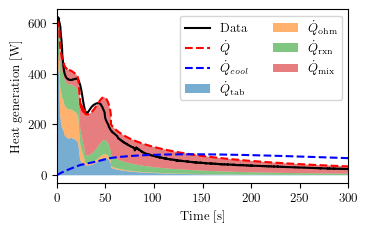

In [20]:
%matplotlib inline
plt.close('all')

solution = solutions_fit[0]
data = load_data(1, '100A')[0]
# vars to plot
Qs = [
    'Tab heating [W]',
    'Ohmic heating [W]',
    'Irreversible electrochemical heating [W]',
    'Heat of mixing [W]',
    # 'SEI decomposition heating [W.m-3]',
]
labels = [
    '$\dot{Q}_\mathrm{{tab}}$',
    '$\dot{Q}_\mathrm{{ohm}}$',
    '$\dot{Q}_\mathrm{{rxn}}$',
    '$\dot{Q}_\mathrm{{mix}}$',
    # '$\dot{Q}_\mathrm{{SEI}}$',
]

# plot total 
t = solution['Time [s]'].entries
xlabel = "Time [s]"
fig, ax = plt.subplots(1,  1, figsize=(4, 2.5), sharex=True, constrained_layout=True)#, constrained_layout=True
sim_colors = ['r', 'b', 'limegreen','darkorange', 'm']


Q_total = (solution['Total heating [W]'].entries)#*V_cell
ax.plot(data.t, data.I*(ocv(data.SOC)-data.V), color = 'k', label = "Data")# (RMSE = " + str(np.round(rmse_T_pybamm, 1)) + '$^\circ$C)')
ax.plot(t, Q_total, color = 'r', linestyle = '--', label = '$\dot{Q}$') #$_\mathrm{{total}}$
Q_cool = solution['Lumped total cooling [W]'].entries
ax.plot(t, -Q_cool, color = 'b', linestyle = '--', label = '$\dot{Q}_{cool}$') #$_\mathrm{{total}}$

bottom = [0]*len(t)
for i, (Q,label) in enumerate(zip(Qs, labels)): 
    top = bottom + solution[Q](t)#*V_cell
    ax.fill_between(t, bottom, top, alpha = 0.6, label=label)
    bottom = top
    
ax.set_xlim(0,300)
ax.set_xlabel(xlabel)
ax.set_ylabel('Heat generation [W]')
# handles, labels = ax.get_legend_handles_labels()
plt.legend(loc = 'upper right', ncol=2)
plt.savefig('./figs/heat_component.eps', format='eps', dpi = 300)
plt.tight_layout()
plt.show()

In [21]:
%matplotlib inline
plt.close('all')

pybamm.QuickPlot(solution,[
    "Heat of mixing [W]",
    # ['Average negative particle concentration',
    # 'Average negative particle stoichiometry',
    # 'X-averaged negative electrode surface potential difference [V]',
    # 'X-averaged positive electrode surface potential difference [V]',
    # "X-averaged positive electrode interfacial current density [A.m-2]",
    # 'X-averaged positive electrode exchange current density [A.m-2]',
    # 'Negative electrode volumetric interfacial current density [A.m-2]',
    # "X-averaged negative electrode interfacial current density [A.m-2]",
    ]).dynamic_plot()
# ax.set_ylim([0,1e3])

interactive(children=(FloatSlider(value=0.0, description='t', max=899.9000000000001, step=8.999), Output()), _…

# Archive

In [17]:
param = pybamm.ParameterValues('Tran2023')

fig, ax = plt.subplots(5,  len(SOC_names), figsize=(12, 10), sharex=True, gridspec_kw = {'wspace':0.3, 'hspace':0.1}, constrained_layout=True)#, constrained_layout=True
# ax = ax.flatten()
linestyles = ['--',':','-.']*2
sim_colors = ['r','g','b','m']

# for each cell...
for i, (solution,data) in enumerate(zip(solutions_iso, datas)):    
    SOC_0 = SOC_0s[SOC_names[i]]

    # plot
    t = solution["Time [s]"].entries
    x = solution["x [m]"].entries[:, 0]
    x_plot = t
    xlabel = "Time [s]"
    data_color = 'k'
    sim_color = 'r' #sim_colors[i]
    sim_ls = '--'

    I = solution['C-rate']
    e_I = I(t=data.t)  - data.I/param['Nominal cell capacity [A.h]'] 
    ax[0,i].plot(data.t,data.I/param['Nominal cell capacity [A.h]'], label='Data',color = data_color)
    ax[0,i].plot(x_plot, I(t), linestyle='--', color = sim_color, label='Model')
    # ax[0,i].plot(data.t,e_I, linestyle=':', label='_nolegend_',color = sim_color)
    # ax[0,i].set_xlabel(xlabel)
    ax[0,i].set_ylabel('C-rate', labelpad=0)
    ax[0,i].set_title(SOC_names[i] + "\% SOC$_0$")
    ax[0,i].set_ylim([0,80])

    V = solution['Terminal voltage [V]']
    ax[1,i].plot(data.t, data.V,color = data_color)
    ax[1,i].plot(x_plot, V(t),linestyle=sim_ls, color = sim_color)
    # ax[1,i].set_xlabel(xlabel)
    ax[1,i].set_ylabel('Terminal voltage [V]')
    ax[1,i].set_ylim([0,2])

    T = solution['Volume-averaged cell temperature [K]'].entries - 273.15
    ax[2,i].plot(data.t, data.Temp,color = data_color)
    ax[2,i].plot(x_plot, T,linestyle=sim_ls, color = sim_color)  
    # ax[2,i].set_xlabel(xlabel)
    ax[2,i].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
    ax[2,i].set_ylim([0,150])

    soc = SOC_0 - integrate.cumtrapz(I(t),t)/3600
    soc = np.insert(soc,0,SOC_0)
    ax[3,i].plot(data.t, data.SOC,color = data_color)
    ax[3,i].plot(x_plot, soc,linestyle='--', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
    # ax[3,i].plot(data.t, e_soc,linestyle=':', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
    # ax[3,i].set_xlabel(xlabel)
    ax[3,i].set_ylabel('SOC',labelpad=0)
    ax[3,i].set_ylim([0,1])

    sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
    data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0
    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    sigma = solution["Cell expansion stress [kPa]"].entries
    sigma_plot = sigma.copy()
    vent_check = np.argmax(sigma_plot>sigma_max)
    if vent_check > 0:
        sigma_plot[vent_check::] = 0  
    ax[4,i].plot(data.t, data_sigma, color = data_color) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    ax[4,i].plot([x_plot[0], x_plot[-1]], sigma_max*np.array([1,1]) , linestyle=':', color = data_color) #(out.P_est-P_atm)/1000-sigma_0/1000
    ax[4,i].plot(x_plot, sigma_plot,linestyle=sim_ls, color = sim_color)
    ax[4,i].set_ylim([0,70])
    ax[4,i].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    ax[4,i].set_xlabel(xlabel)

    if SOC_0==1:# and (l == len(solutions)-1):
        for j in range(0,5):
            t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
            T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
            ylims = ax[j,i].get_ylim()
            ax[j,i].plot([t_vent]*2, list(ylims), color = 'm', linestyle = ':')
            ax[j,i].annotate('Venting', xy=(t_vent, np.diff(ylims)*0.5+ ylims[0]), rotation=-90, color = 'm')
            ax[j,i].set_ylim(ylims) # keep original limits


handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, prop={'size': 10},  bbox_to_anchor=(0.5, .95), fancybox=True)
plt.xlim([0,t_end])
plt.tight_layout()
# plt.savefig('./figs/all_ESC_combined_linear.eps', format='eps', dpi = 300)
plt.show()


ValueError: 'Tran2023' is not a valid parameter set. Parameter set must be one of:
Ai2020
Chen2020
Chen2020_composite
ECM_Example
Ecker2015
Ecker2015_graphite_halfcell
MSMR_Example
Marquis2019
Mohtat2020
NCA_Kim2011
OKane2022
OKane2022_graphite_SiOx_halfcell
ORegan2022
Prada2013
Ramadass2004
Sulzer2019
Xu2019

2023-10-15 03:06:59.344 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2023-10-15 03:06:59.374 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2023-10-15 03:06:59.404 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2023-10-15 03:06:59.422 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


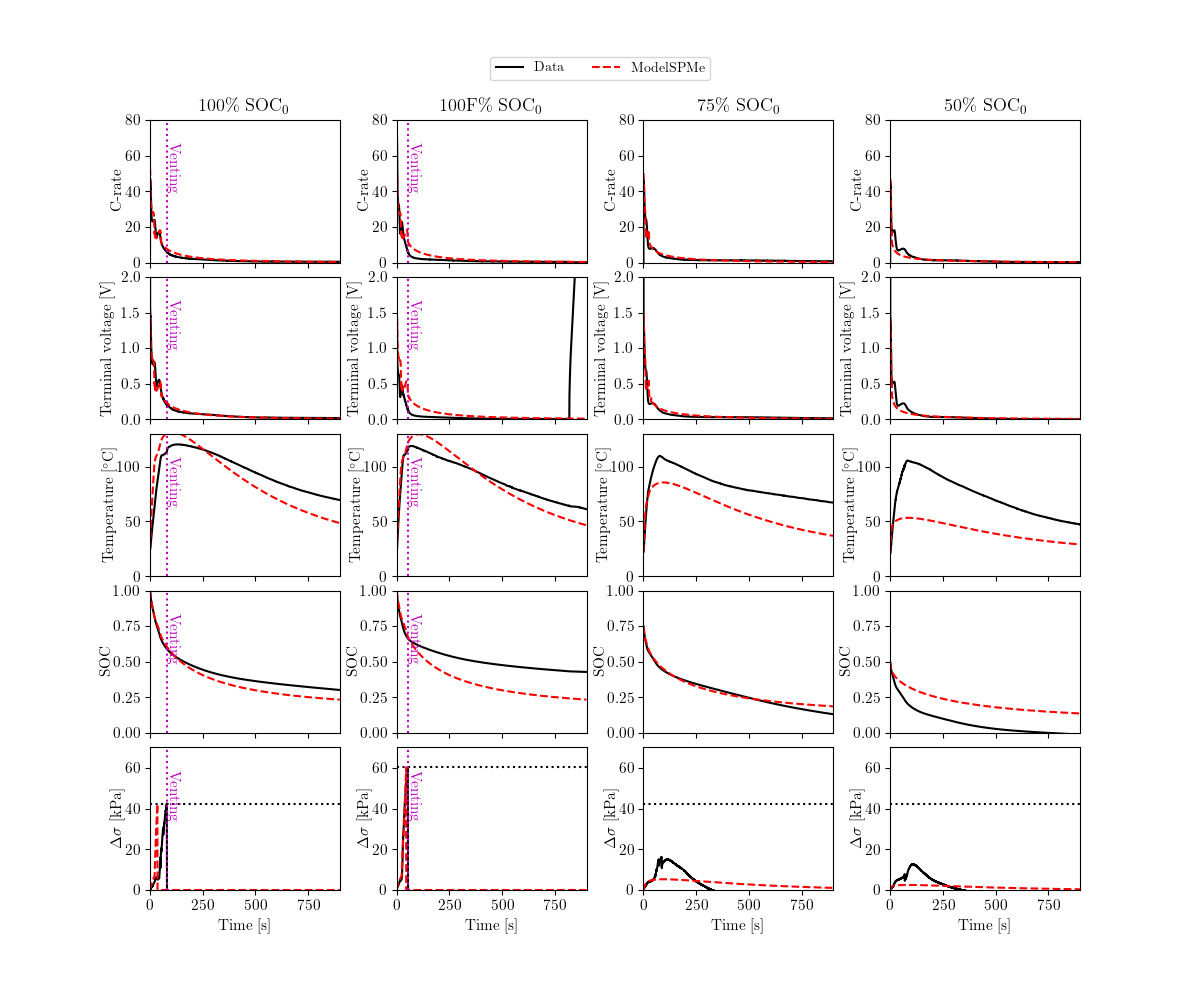

In [ ]:
param = pybamm.ParameterValues('Tran2023')
sim_set_labels = ['SPMe', 'SPMeT']
fig, ax = plt.subplots(5,  len(SOC_names), figsize=(12, 10), sharex=True, gridspec_kw = {'wspace':0.3, 'hspace':0.1}, constrained_layout=True)#, constrained_layout=True
# ax = ax.flatten()
linestyles = ['--',':','-.']*2
sim_colors = ['r','g','b','m']

# for each cell...
for k, solutions in enumerate([solutions_iso, solutions_therm]): 
    for i, (solution, data) in enumerate(zip(solutions, datas)):    
        SOC_0 = SOC_0s[SOC_names[i]]

        # plot
        t = solution["Time [s]"].entries
        x = solution["x [m]"].entries[:, 0]
        x_plot = t
        xlabel = "Time [s]"
        data_color = 'k'
        sim_color = sim_colors[k]
        sim_ls = '--'

        sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
        data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0

        if k ==0: 
            ax[0,i].plot(data.t,data.I/param['Nominal cell capacity [A.h]'], label='Data',color = data_color)
            ax[1,i].plot(data.t, data.V,color = data_color)
            ax[2,i].plot(data.t, data.Temp,color = data_color)
            ax[3,i].plot(data.t, data.SOC,color = data_color)
            ax[4,i].plot(data.t, data_sigma, color = data_color) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000

        I = solution['C-rate']
        e_I = I(t=data.t)  - data.I/param['Nominal cell capacity [A.h]'] 
        ax[0,i].plot(x_plot, I(t), linestyle='--', color = sim_color, label='Model' + sim_set_labels[k])
        # ax[0,i].plot(data.t,e_I, linestyle=':', label='_nolegend_',color = sim_color)
        # ax[0,i].set_xlabel(xlabel)
        ax[0,i].set_ylabel('C-rate', labelpad=0)
        ax[0,i].set_title(SOC_names[i] + "\% SOC$_0$")
        ax[0,i].set_ylim([0,80])

        V = solution['Terminal voltage [V]']
        ax[1,i].plot(x_plot, V(t),linestyle=sim_ls, color = sim_color)
        # ax[1,i].set_xlabel(xlabel)
        ax[1,i].set_ylabel('Terminal voltage [V]')
        ax[1,i].set_ylim([0,2])

        T = solution['Volume-averaged cell temperature [K]'].entries - 273.15
        ax[2,i].plot(x_plot, T,linestyle=sim_ls, color = sim_color)  
        # ax[2,i].set_xlabel(xlabel)
        ax[2,i].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
        ax[2,i].set_ylim([0,130])

        soc = SOC_0 - integrate.cumtrapz(I(t),t)/3600
        soc = np.insert(soc,0,SOC_0)
        ax[3,i].plot(x_plot, soc,linestyle='--', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
        # ax[3,i].plot(data.t, e_soc,linestyle=':', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
        # ax[3,i].set_xlabel(xlabel)
        ax[3,i].set_ylabel('SOC',labelpad=0)
        ax[3,i].set_ylim([0,1])

        sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
        sigma = solution["Cell expansion stress [kPa]"].entries
        sigma_plot = sigma.copy()
        vent_check = np.argmax(sigma_plot>sigma_max)
        if vent_check > 0:
            sigma_plot[vent_check::] = 0  
        ax[4,i].plot([x_plot[0], x_plot[-1]], sigma_max*np.array([1,1]) , linestyle=':', color = data_color) #(out.P_est-P_atm)/1000-sigma_0/1000
        ax[4,i].plot(x_plot, sigma_plot,linestyle=sim_ls, color = sim_color)
        ax[4,i].set_ylim([0,70])
        ax[4,i].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
        ax[4,i].set_xlabel(xlabel)

        if SOC_0==1:# and (l == len(solutions)-1):
            for j in range(0,5):
                t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
                T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
                ylims = ax[j,i].get_ylim()
                ax[j,i].plot([t_vent]*2, list(ylims), color = 'm', linestyle = ':')
                ax[j,i].annotate('Venting', xy=(t_vent, np.diff(ylims)*0.5+ ylims[0]), rotation=-90, color = 'm')
                ax[j,i].set_ylim(ylims) # keep original limits


handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, .95), fancybox=True)
plt.xlim([0,t_end])
plt.tight_layout()
plt.savefig('./figs/all_ESC_combined_linear_therm_vs_iso.eps', format='eps', dpi = 300)
plt.show()


2023-10-15 02:48:06.549 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2023-10-15 02:48:06.585 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2023-10-15 02:48:06.617 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2023-10-15 02:48:06.639 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


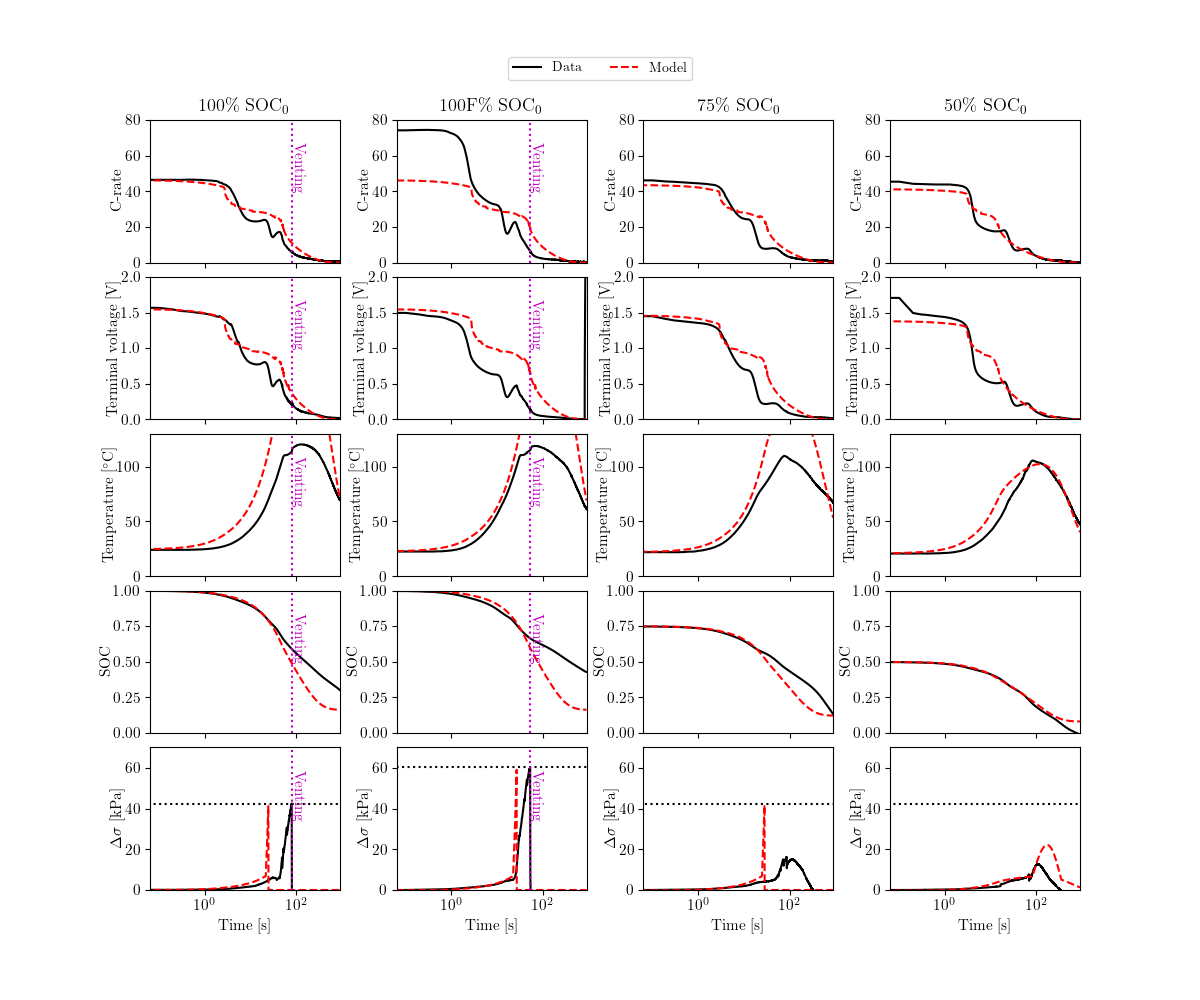

In [ ]:
param = pybamm.ParameterValues('Tran2023')

fig, ax = plt.subplots(5,  len(SOC_names), figsize=(12, 10), sharex=True, gridspec_kw = {'wspace':0.3, 'hspace':0.1}, constrained_layout=True)#, constrained_layout=True
# ax = ax.flatten()
linestyles = ['--',':','-.']*2
sim_colors = ['r','g','b','m']

# for each cell...
for i, (solution,data) in enumerate(zip(solutions, datas)):    
    SOC_0 = SOC_0s[SOC_names[i]]

    # plot
    t = solution["Time [s]"].entries
    x = solution["x [m]"].entries[:, 0]
    x_plot = t
    xlabel = "Time [s]"
    data_color = 'k'
    sim_color = 'r' #sim_colors[i]
    sim_ls = '--'

    I = solution['C-rate']
    e_I = I(t=data.t)  - data.I/param['Nominal cell capacity [A.h]'] 
    ax[0,i].semilogx(data.t,data.I/param['Nominal cell capacity [A.h]'], label='Data',color = data_color)
    ax[0,i].semilogx(x_plot, I(t), linestyle='--', color = sim_color, label='Model')
    # ax[0,i].plot(data.t,e_I, linestyle=':', label='_nolegend_',color = sim_color)
    # ax[0,i].set_xlabel(xlabel)
    ax[0,i].set_ylabel('C-rate', labelpad=0)
    ax[0,i].set_title(SOC_names[i] + "\% SOC$_0$")
    ax[0,i].set_ylim([0,80])

    V = solution['Terminal voltage [V]']
    ax[1,i].semilogx(data.t, data.V,color = data_color)
    ax[1,i].semilogx(x_plot, V(t),linestyle=sim_ls, color = sim_color)
    # ax[1,i].set_xlabel(xlabel)
    ax[1,i].set_ylabel('Terminal voltage [V]',labelpad=0)
    ax[1,i].set_ylim([0,2])

    T = solution['Volume-averaged cell temperature [K]'].entries - 273.15
    ax[2,i].semilogx(data.t, data.Temp,color = data_color)
    ax[2,i].semilogx(x_plot, T,linestyle=sim_ls, color = sim_color)  
    # ax[2,i].set_xlabel(xlabel)
    ax[2,i].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
    ax[2,i].set_ylim([0,130])

    soc = SOC_0 - integrate.cumtrapz(I(t),t)/3600
    soc = np.insert(soc,0,SOC_0)
    ax[3,i].semilogx(data.t, data.SOC,color = data_color)
    ax[3,i].semilogx(x_plot, soc,linestyle='--', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
    # ax[3,i].plot(data.t, e_soc,linestyle=':', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
    # ax[3,i].set_xlabel(xlabel)
    ax[3,i].set_ylabel('SOC',labelpad=0)
    ax[3,i].set_ylim([0,1])

    sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
    data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0
    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    sigma = solution["Cell expansion stress [kPa]"].entries
    sigma_plot = sigma.copy()
    vent_check = np.argmax(sigma_plot>sigma_max)
    if vent_check > 0:
        sigma_plot[vent_check::] = 0  
    ax[4,i].semilogx(data.t, data_sigma, color = data_color) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    ax[4,i].semilogx([x_plot[0], x_plot[-1]], sigma_max*np.array([1,1]) , linestyle=':', color = data_color) #(out.P_est-P_atm)/1000-sigma_0/1000
    ax[4,i].semilogx(x_plot, sigma_plot,linestyle=sim_ls, color = sim_color)
    ax[4,i].set_ylim([0,70])
    ax[4,i].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    ax[4,i].set_xlabel(xlabel)

    if SOC_0==1:# and (l == len(solutions)-1):
        for j in range(0,5):
            t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
            T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
            ylims = ax[j,i].get_ylim()
            ax[j,i].plot([t_vent]*2, list(ylims), color = 'm', linestyle = ':')
            ax[j,i].annotate('Venting', xy=(t_vent, np.diff(ylims)*0.5+ ylims[0]), rotation=-90, color = 'm')
            ax[j,i].set_ylim(ylims) # keep original limits


handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, prop={'size': 10},  bbox_to_anchor=(0.5, .95), fancybox=True)
plt.xlim([0,t_end])
plt.tight_layout()
plt.savefig('./figs/all_ESC_combined_log.eps', format='eps', dpi = 300)
plt.show()
